In [2]:
import pandas as pd

df = pd.read_csv(r'C:\Users\prave\OneDrive\data.csv')
df.head()


,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo,valence,year
0,0.995,['Carl Woitschach'],0.708,158648,0.1950,0,6KbQ3uYMLKb5jDxLF7wYDD,0.563,10,0.1510,-12.428,1,Singende Bataillone 1. Teil,0,1928,0.0506,118.469,0.7790,1928
1,0.994,"['Robert Schumann', 'Vladimir Horowitz']",0.379,282133,0.0135,0,6KuQTIu1KoTTkLXKrwlLPV,0.901,8,0.0763,-28.454,1,"Fantasiestücke, Op. 111: Più tosto lento",0,1928,0.0462,83.972,0.0767,1928
2,0.604,['Seweryn Goszczyński'],0.749,104300,0.2200,0,6L63VW0PibdM1HDSBoqnoM,0.000,5,0.1190,-19.924,0,Chapter 1.18 - Zamek kaniowski,0,1928,0.9290,107.177,0.8800,1928
3,0.995,['Francisco Canaro'],0.781,180760,0.1300,0,6M94FkXd15sOAOQYRnWPN8,0.887,1,0.1110,-14.734,0,Bebamos Juntos - Instrumental (Remasterizado),0,1928-09-25,0.0926,108.003,0.7200,1928
4,0.990,"['Frédéric Chopin', 'Vladimir Horowitz']",0.210,687733,0.2040,0,6N6tiFZ9vLTSOIxkj8qKrd,0.908,11,0.0980,-16.829,1,"Polonaise-Fantaisie in A-Flat Major, Op. 61",1,1928,0.0424,62.149,0.0693,1928


In [3]:

print(df.shape)


print(df.columns)


print(df.isnull().sum())


(169909, 19)
Index(['acousticness', 'artists', 'danceability', 'duration_ms', 'energy',
       'explicit', 'id', 'instrumentalness', 'key', 'liveness', 'loudness',
       'mode', 'name', 'popularity', 'release_date', 'speechiness', 'tempo',
       'valence', 'year'],
      dtype='object')
acousticness        0
artists             0
danceability        0
duration_ms         0
energy              0
explicit            0
id                  0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
name                0
popularity          0
release_date        0
speechiness         0
tempo               0
valence             0
year                0
dtype: int64


In [4]:

df = df.drop_duplicates()


df = df.dropna()

print(df.shape)  


(169909, 19)


In [5]:

most_popular = df[df['popularity'] == df['popularity'].max()][['name', 'artists', 'popularity']]
print("Most Popular Song:")
print(most_popular)
avg_popularity = df.groupby('year')['popularity'].mean()
print("\nAverage Popularity by Year:")
print(avg_popularity.tail(20))  
avg_danceability = df.groupby('year')['danceability'].mean()
print("\nAverage Danceability by Year:")
print(avg_danceability.tail(20))


Most Popular Song:
                  name         artists  popularity
87942  Blinding Lights  ['The Weeknd']         100

Average Popularity by Year:
year
2001    48.624500
2002    48.202000
2003    48.404500
2004    48.974000
2005    50.347500
2006    50.631000
2007    50.708500
2008    50.522000
2009    51.360000
2010    52.763500
2011    53.184000
2012    54.340000
2013    55.691500
2014    56.964500
2015    59.547903
2016    61.371254
2017    64.861500
2018    67.276000
2019    69.655500
2020    63.111048
Name: popularity, dtype: float64

Average Danceability by Year:
year
2001    0.585933
2002    0.578628
2003    0.576633
2004    0.572262
2005    0.576301
2006    0.568445
2007    0.564830
2008    0.583410
2009    0.566857
2010    0.577811
2011    0.559822
2012    0.571695
2013    0.578874
2014    0.589574
2015    0.591008
2016    0.599976
2017    0.612286
2018    0.664930
2019    0.644215
2020    0.673077
Name: danceability, dtype: float64


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")  


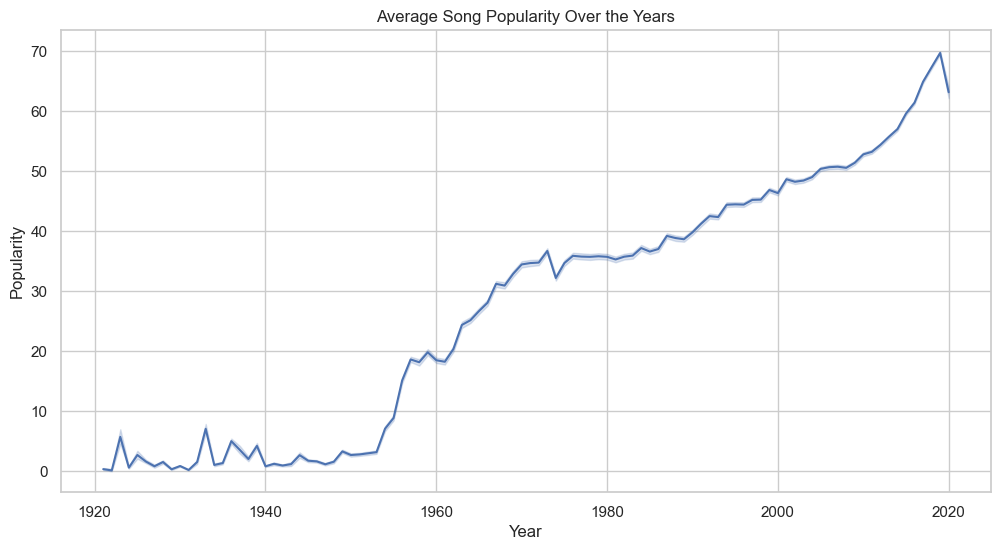

In [7]:
plt.figure(figsize=(12,6))
sns.lineplot(x='year', y='popularity', data=df)
plt.title("Average Song Popularity Over the Years")
plt.xlabel("Year")
plt.ylabel("Popularity")
plt.show()


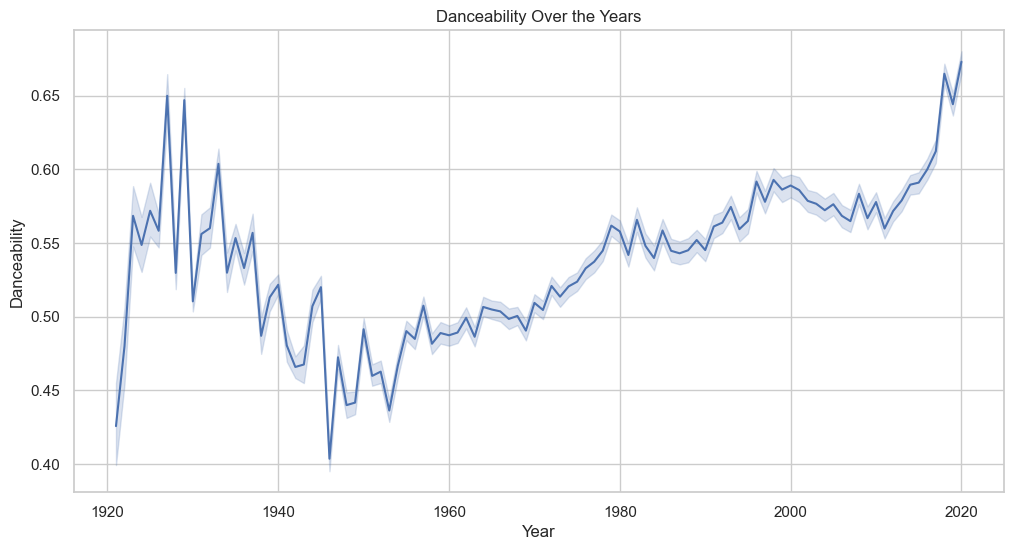

In [8]:
plt.figure(figsize=(12,6))
sns.lineplot(x='year', y='danceability', data=df)
plt.title("Danceability Over the Years")
plt.xlabel("Year")
plt.ylabel("Danceability")
plt.show()


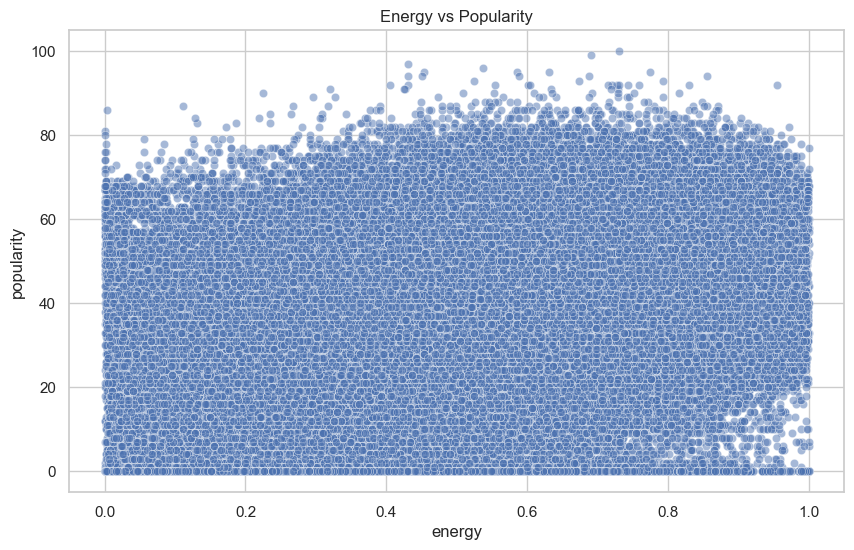

In [9]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='energy', y='popularity', data=df, alpha=0.5)
plt.title("Energy vs Popularity")
plt.show()


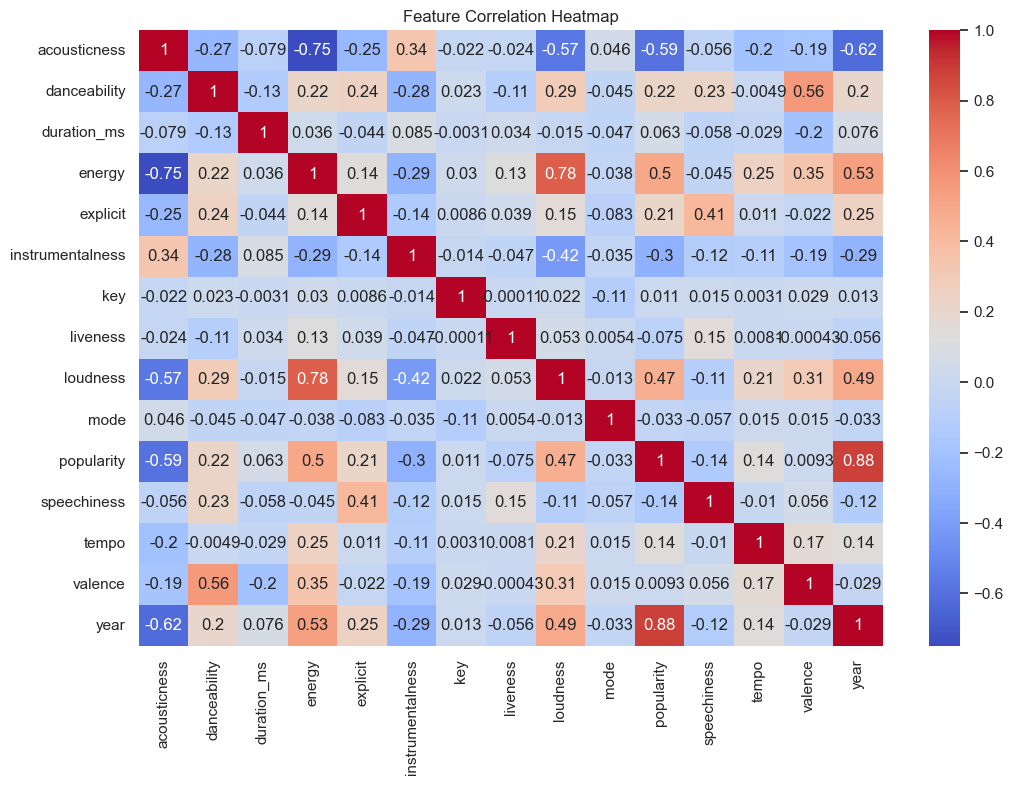

In [10]:
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


In [11]:
top_artists = df.groupby('artists')['popularity'].mean().sort_values(ascending=False).head(10)
print("Top 10 Artists by Average Popularity:")
print(top_artists)


Top 10 Artists by Average Popularity:
artists
['Powfu', 'beabadoobee']                         97.0
['BENEE', 'Gus Dapperton']                       95.0
['Surf Mesa', 'Emilee']                          95.0
['Ariana Grande', 'Justin Bieber']               94.0
['StaySolidRocky']                               94.0
['KAROL G', 'Nicki Minaj']                       92.0
['Bad Bunny', 'Jowell & Randy', 'Nengo Flow']    92.0
['Topic', 'A7S']                                 92.0
['Marshmello', 'Halsey']                         91.0
['Lady Gaga', 'Ariana Grande']                   90.5
Name: popularity, dtype: float64


In [12]:
top_songs = df.loc[df.groupby('year')['popularity'].idxmax()][['year','name','artists','popularity']]
print("Top Song Each Year:")
print(top_songs.tail(10)) 


Top Song Each Year:
       year                 name                artists  popularity
87041  2011      Pumped Up Kicks  ['Foster The People']          83
87141  2012  When I Was Your Man         ['Bruno Mars']          82
87243  2013            All of Me        ['John Legend']          85
87368  2014           Photograph         ['Ed Sheeran']          83
87440  2015            Play Date   ['Melanie Martinez']          91
87540  2016           goosebumps       ['Travis Scott']          92
87640  2017       Jocelyn Flores       ['XXXTENTACION']          87
87741  2018              Falling      ['Trevor Daniel']          92
87840  2019              The Box        ['Roddy Ricch']          95
87942  2020      Blinding Lights         ['The Weeknd']         100


In [13]:
import os
os.getcwd()


'C:\\Users\\prave'

In [14]:
import os
os.getcwd()

'C:\\Users\\prave'